In [1]:
%run import_libs.py

In [2]:
from preprocess_eye_data import *

# preprocessing (run only if you'd like to readin/preprocess the data)
- if only need to read in data, jump to "readin gaze data (if applicable)" section

In [ ]:
#read in the mega df
root = 'D:/yueying/gazeObject_YueyingDong/'

pathEL = root + "data/goRaw_tracker/"
pathpy = root + "data/goRaw_psychopy/"

readIn = sorted(np.array([f for f in os.listdir(pathEL)]))

93

In [ ]:
readIn = ['311','312', '313', '314','315','316', '317', '318', '319', '320','321', '322','324', '325',
 '326','327', '328','329','330',
 '331','332','333','334','335',
 '336','337','338','339','340','341','342','343','344','345','346','347','348','349','350','351','352',]

In [ ]:
#columns to readin
relevantCols = ['RECORDING_SESSION_LABEL','AVERAGE_GAZE_X',
       'AVERAGE_GAZE_Y','AVERAGE_PUPIL_SIZE','EYE_TRACKED','IP_LABEL','IP_START_TIME',
      'LEFT_PUPIL_SIZE','RIGHT_PUPIL_SIZE','SAMPLE_MESSAGE','TIMESTAMP','TRIALID']
pupCols = ['EYE_TRACKED','LEFT_PUPIL_SIZE','RIGHT_PUPIL_SIZE','AVERAGE_PUPIL_SIZE',
           'IP_LABEL','TIMESTAMP','TRIALID']
selectEye = 'AVERAGE_PUPIL_SIZE'
included = 6500

6500

In [ ]:
#record any subject who we only tracked one eye
rightEyeSubj = ['333','345','347']
leftEyeSubj = ['316','310','321','326','333','334','336','337','340','341','373','396']

In [ ]:
#readIn raw files
runReadin = input()
if runReadin == 'y':
    #for recording everyone's preprocessed data along with saccade tags
    psyFull = pd.DataFrame()

    pupFullTrial_raw = pd.DataFrame()
    saccFullTrial_x_raw = pd.DataFrame()
    saccFullTrial_y_raw = pd.DataFrame()
    for n,f in enumerate(readIn):

        """ section1: read in """
        f = str(f)
        print('start processing: ' + f)

        #readin eyelink file
        el = pd.read_csv(glob.glob(pathEL+ f + '/*.txt')[0]
                ,delimiter = "\t")#encoding = 'utf-16'
    
        #replace non-sensible values with nans
        el['TRIALID'] = el.TRIALID.replace('UNDEFINED',np.nan)
        el = el[~el.TRIALID.isnull()]
        el['SAMPLE_MESSAGE'] = el.SAMPLE_MESSAGE.replace('.',np.nan).ffill()

        #for a few subjs, we only tracked one eye, select this eye's data
        selectEye = 'AVERAGE_PUPIL_SIZE'
        if f in leftEyeSubj:
            selectEye = 'LEFT_PUPIL_SIZE'
        elif f in rightEyeSubj:
            selectEye = 'RIGHT_PUPIL_SIZE'
        elif el.EYE_TRACKED.iloc[0] != 'Binocular':
            selectEye = el.EYE_TRACKED.iloc[0].upper()+ '_PUPIL_SIZE'

        #after reading in el file, transform to trial * timestamp structure
        pseudodf = el 

        pseudodf = pseudodf.rename(columns={selectEye:'pupSize','TIMESTAMP':'pupil_timestamp'}).reset_index(drop = True)
        pseudodf['pupSize'] = pd.to_numeric(pseudodf['pupSize'].replace('.',0))
        pseudodf['AVERAGE_GAZE_X'] = pd.to_numeric(pseudodf['AVERAGE_GAZE_X'].replace('.',np.nan))
        pseudodf['AVERAGE_GAZE_Y'] = pd.to_numeric(pseudodf['AVERAGE_GAZE_Y'].replace('.',np.nan))
        pseudodf['eventOnset'] = pseudodf.SAMPLE_MESSAGE.astype(str) #prepare for index for  epoching
        pseudodf['x'] = pseudodf.groupby('TRIALID').cumcount() #prepare for transformation
    
        #pivot, only keep the data before probe (5s of data = 5000 sample points)
        pupRaw = pd.pivot_table(pseudodf[['x','pupSize','TRIALID']],values = 'pupSize',columns = 'x',index = 'TRIALID').reset_index().iloc[:,:included+1]
        saccAllT_X = pd.pivot_table(pseudodf[['x','AVERAGE_GAZE_X','TRIALID']],values = 'AVERAGE_GAZE_X',columns = 'x',index = 'TRIALID').reset_index().iloc[:,:included+1]
        saccAllT_Y = pd.pivot_table(pseudodf[['x','AVERAGE_GAZE_Y','TRIALID']],values = 'AVERAGE_GAZE_Y',columns = 'x',index = 'TRIALID').reset_index().iloc[:,:included+1]
    
        #concate
        print('     start concate: ' + f)

        #pupil
        pupFullTrial_raw = pd.concat([pupFullTrial_raw,pupRaw])
        #sacc
        saccFullTrial_x_raw = pd.concat([saccFullTrial_x_raw,saccAllT_X])
        saccFullTrial_y_raw = pd.concat([saccFullTrial_y_raw,saccAllT_Y])



In [44]:
psyFull = pd.DataFrame()
conAll = pd.DataFrame()
for f in readIn:
    f = str(f)

    trlInfo = pd.read_csv(glob.glob(pathpy+f+ '/*.csv')[0])
    try:
        trlInfo = trlInfo[(trlInfo.is_practice!=True)& (trlInfo.TRIALID.isnull() == False)]
    except AttributeError:
        trlInfo = trlInfo[(trlInfo.TRIALID.isnull() == False)]
        
    psyFull = pd.concat([psyFull,trlInfo])
psyFull = psyFull.drop_duplicates().reset_index(drop = True)

In [ ]:
try:
    #view distribution of pupil size data
    pupDat = pupFullTrial_raw.iloc[:,1:].values.flatten()
    plt.hist(pupDat,bins = 50)
except NameError:
    pass

### determine the rejection criteria from the pupil data

In [ ]:
#run the preprocessing if the raw file has been readin
if pupFullTrial_raw.shape[0] != 0:
    """for pupil data, apply the speed filter (dBlink)"""
    #Clean once
    cleanOnce = pupFullTrial_raw.iloc[:,1:].apply(lambda x: deBlink(rawPup = x.astype(float),timestamp = np.linspace(0,5,len(x)),
                                                borderlenBef= 0.05, borderlenAft = 0.2,minAllowedPup = 2000,
                                                clusterLapse = 0.05, madThreshold = 10),axis = 1,raw = True)

    #smooth the resulting array using rolling window of size 11
    onceSmooth = cleanOnce.rolling(11,min_periods=1,center  = True,axis =1).mean()

    #second clean, this is to get rid of any residual outlier
    cleanTwice = onceSmooth.apply(lambda x: deBlink(rawPup = x,timestamp = np.linspace(0,5,len(x)),minAllowedPup = 2000,
                                            borderlenBef = 0.05,borderlenAft = 0.05,minGapt = 0.002,
                                            clusterLapse = 0.05,madThreshold = 12),axis =1,raw = True)
    
    #reset Index, add back the trial id
    pupFullTrial = cleanTwice.reset_index(drop = True)
    pupFullTrial.insert(0,'TRIALID',pupFullTrial_raw.TRIALID.values)

    """for pupil data only, mask off data using a size filter"""
    #mask off any pupil data that exceed a median +- n*medianSD threshold for that subject
    sdThreshold = 6
    stdmask = pd.DataFrame()
    temp = pupFullTrial.merge(psyFull[['participant','TRIALID']],how = 'left',
                    left_on='TRIALID', right_on='TRIALID')

    for i in temp.participant.unique():
        tempdf = temp[temp.participant == i]

        #calculate upper/lower bounds
        stdupper = np.nanmedian(tempdf.iloc[:,1:included+1])  + sdThreshold* medianVariance(tempdf.iloc[:,1:included+1])
        stdlower = np.nanmedian(tempdf.iloc[:,1:included+1])  - sdThreshold* medianVariance(tempdf.iloc[:,1:included+1])
        #create std mask for this subj
        stdmask_temp = (tempdf.iloc[:,1:included+1] > stdupper) | (tempdf.iloc[:,1:included+1] < stdlower)
        stdmask_temp.insert(0,'TRIALID',tempdf.TRIALID)
        
        stdmask = pd.concat([stdmask,stdmask_temp])
    
    # reject the invalid data that's outside of the threshold
    pupFullTrial.iloc[:,1:] = pupFullTrial.iloc[:,1:].mask(stdmask.iloc[:,1:],np.nan)

  

In [16]:
#keep the trial if it has more than 90% data retained in the period of interest
#trialwise
pupClean = pupFullTrial[(pupFullTrial.iloc[:,500:-500].isnull().sum(axis = 1)) < (0.2* 5500)] .reset_index(drop = True)

#look at the trial remain
pd.DataFrame([ast.literal_eval(i)[0] for i in pupClean['TRIALID']]).value_counts()


0     
400       319
375       319
366       319
377       319
364       318
379       318
365       317
388       317
360       317
390       316
389       316
380       316
398       314
371       314
369       313
386       310
387       309
376       309
378       308
395       307
363       307
391       305
368       302
381       302
396       299
112430    298
370       298
373       297
399       297
374       292
393       291
392       285
367       284
362       275
385       272
394       271
383       269
382       264
397       262
384       255
372       255
Name: count, dtype: int64

In [17]:
pupClean.shape

(12275, 6501)

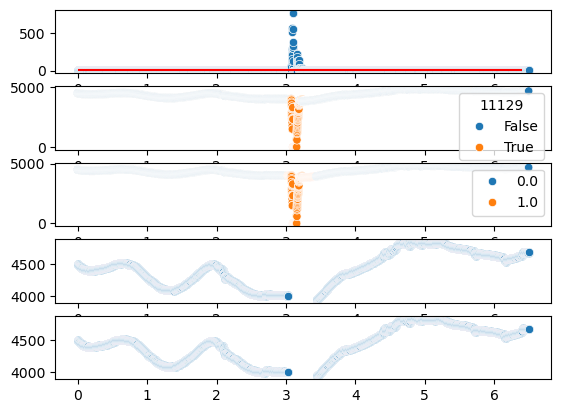

In [24]:
#look at an examplar trial for the blink mask 

try:
    eg = random.randint(0,len(pupFullTrial_raw))
    deBlink(rawPup = pupFullTrial_raw.iloc[eg,1:].astype(float),timestamp = np.linspace(0,included/1000,len(pupFullTrial_raw.iloc[eg,1:])),
                                                borderlenBef= 0.05, borderlenAft = 0.2,minAllowedPup = 2000,
                                                clusterLapse = 0.05, madThreshold = 10,plotSteps=True)#returnMask = True,
except:
    pass

## clean eye movement data

In [ ]:

if pupFullTrial_raw.shape[0] != 0:

    """generate the gaze mask, to filter out """
    #also return the blink mask; the mask have a high positive rate, i set the mad threshold (mad = 12) to be higher to 
    #decrease the false positive
    maskClean = pupFullTrial_raw.iloc[:,1:].apply(lambda x: deBlink(rawPup = x.astype(float),timestamp = np.linspace(0,included/1000,len(x)),
                                                borderlenBef= 0.05, borderlenAft = 0.05,minAllowedPup = 2000,
                                                clusterLapse = 0.03, madThreshold = 12,returnMask = True),axis = 1,raw = True)
    maskClean.insert(0,'TRIALID',pupFullTrial_raw.TRIALID)

    #find trials that are in both saccfull and in mask (this is just a safty check)
    sharedTrl = list(set(saccFullTrial_x_raw.TRIALID) & set(maskClean.TRIALID))
    gazeMask = maskClean[maskClean.TRIALID.isin(sharedTrl)].sort_values('TRIALID').reset_index(drop = True)
    stdmask2 = stdmask[stdmask.TRIALID.isin(sharedTrl)].sort_values('TRIALID').reset_index(drop = True)

    #further filter by the pupil std mask
    gazeMask.iloc[:,1:] = pd.DataFrame( gazeMask.iloc[:,1:].values.astype(bool)|
                                       stdmask2.iloc[:,1:].values.astype(bool))#cleanTwiceMask.iloc[:,1:].values.astype(bool) |

    saccTemp_x = saccFullTrial_x_raw[saccFullTrial_x_raw.TRIALID.isin(sharedTrl)].sort_values('TRIALID').reset_index(drop = True)
    saccTemp_y = saccFullTrial_y_raw[saccFullTrial_y_raw.TRIALID.isin(sharedTrl)].sort_values('TRIALID').reset_index(drop = True)

    #sanity check, the trial label should be the same, if not raise error
    if (sum(gazeMask.TRIALID != saccTemp_x.TRIALID) == 0) & (sum(gazeMask.TRIALID != saccTemp_y.TRIALID) == 0):
        #put the mask on
        saccTemp_x.iloc[:,1:] = saccTemp_x.iloc[:,1:].mask(gazeMask.iloc[:,1:].astype(bool),np.nan)
        saccTemp_y.iloc[:,1:] = saccTemp_y.iloc[:,1:].mask(gazeMask.iloc[:,1:].astype(bool),np.nan)
    else:
        raise('TRIALID mismatch between saccade raw and saccade mask')
    
    #aggregate the sacc temp x and y dfs
    saccTemp_x['axis'] = 'x'
    saccTemp_y['axis'] = 'y'
    saccTemp = pd.concat([saccTemp_x,saccTemp_y]).reset_index(drop = True)

    trlsKept = pupClean.TRIALID
    saccTemp = saccTemp[saccTemp.TRIALID.isin(trlsKept)].reset_index()

    """interpolation"""
    #anti-aliasing for interpolation
    saccTemp2 = saccTemp.iloc[:,1:].rolling(11,min_periods=1,center  = True,axis =1).mean()

    #interpolation of gaze data
    x = np.linspace(0,5,included)
    saccClean = saccTemp2.iloc[:,:included].apply(lambda y: linearInterpolate(x,y,method='nearest'),axis = 1,raw = True)
    saccClean.insert(0,'TRIALID',saccTemp.TRIALID)
    saccClean.insert(0,'axis',saccTemp.axis)
    saccClean.set_index(['axis'],inplace=True)

    """rejecting trials"""
    #drop trials with all null
    nullTrls = saccClean[(saccClean.iloc[:,500:-500].isnull().sum(axis = 1)) >= (0.2* 5500)].TRIALID
    saccClean = saccClean[~saccClean.TRIALID.isin(nullTrls)]


# readin gaze data

In [ ]:
saccClean = pd.DataFrame()
for i in glob.glob('D:/yueying/gazeObject_YueyingDong/results/data/gazeClean/*.csv')[2:]:#360to400
 saccClean = pd.concat([saccClean,pd.read_csv(i).iloc[:,:]],axis = 0)

saccClean.set_index('axis',inplace=True)

In [ ]:
psyFull = pd.DataFrame()
for i in glob.glob('D:/yueying/gazeObject_YueyingDong/results/data/psychopy/*.csv')[2:]:#360to400
 psyFull = pd.concat([psyFull,pd.read_csv(i).iloc[:,:]],axis = 0)

psyFull = psyFull.reset_index(drop=True)

# extract saccade info

## 

In [32]:
#minimum distance required for a gaze shift to be 
#counted as saccade (5pixel) in either direction
xShiftMin = 8
yShiftMin = 8

In [33]:
"""calculate gaze shift"""

#i used a higher smooth value for y because its is more noisy
smoothSaccX = saccClean.loc['x'].iloc[:,1:].apply(lambda x: smooth(x,window_len=51),axis =1,raw = True)
smoothSaccY = saccClean.loc['y'].iloc[:,1:].apply(lambda x: smooth(x,window_len=51),axis =1,raw = True)


#initialize empty sacc array
shiftDf_relX = np.zeros(shape = smoothSaccX.shape)#relative shift direction in regard to each saccadic movement
shiftDf_relY = np.zeros(shape = smoothSaccY.shape)

# calculate the shift
for i,(x,y) in enumerate(zip(smoothSaccX.values,smoothSaccY.values)):
    shiftDf_relX[i] = findGazeShift2d(x,y,
                           shiftmin = 0,threshold = 6,)
    shiftDf_relY[i] = findGazeShift2d(y,x,
                           shiftmin = 0,threshold = 6)


"""filter out drifts that's too small"""
shiftDf_relX = np.where(((abs(shiftDf_relX) > xShiftMin) | (abs(shiftDf_relY) > yShiftMin)),shiftDf_relX,0)
shiftDf_relY = np.where(((abs(shiftDf_relX) > xShiftMin) | (abs(shiftDf_relY) > yShiftMin)),shiftDf_relY,0)



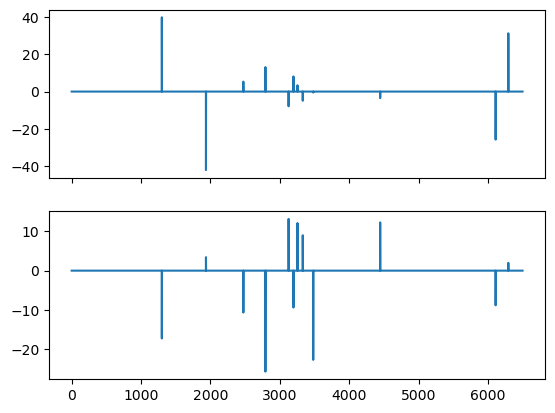

In [34]:
fig,ax = plt.subplots(nrows = 2,sharex=True)
ax[0].plot(shiftDf_relX[4])
ax[1].plot(shiftDf_relY[4])

In [37]:

stimStart = 500
stimEnds = 1500
delayStart = 4000
delayEnds = 5000
"""
#precue
stimStart = 1500
stimEnds = 2500
delayStart = 4000
delayEnds = 5000
"""


'\n#precue\nstimStart = 1500\nstimEnds = 2500\ndelayStart = 4000\ndelayEnds = 5000\n'

In [38]:
"""select the epoch of interest: stim, delay"""
#select for x
shiftX_stim = shiftDf_relX[:,stimStart:stimEnds]
shiftX_delay = shiftDf_relX[:,delayStart:delayEnds]
#select for y
shiftY_stim = shiftDf_relY[:,stimStart:stimEnds]
shiftY_delay = shiftDf_relY[:,delayStart:delayEnds]

"""calculate the eucledian distance traveled"""
saccDist_stim = np.sqrt(shiftX_stim**2 + shiftY_stim**2).sum(axis = 1)
saccDist_delay = np.sqrt(shiftX_delay**2 + shiftY_delay**2).sum(axis = 1)

# Figure 1C

In [17]:
task = 'precue'

In [18]:
plotExample = True
if task == 'retrocue':
    goodExample = 265
else:
    goodExample = 10954

In [ ]:
egImage = cv2.imread('images/bear/bear_08s.jpg'.split('/')[-1])
egImage = cv2.cvtColor(egImage, cv2.COLOR_BGR2RGB)


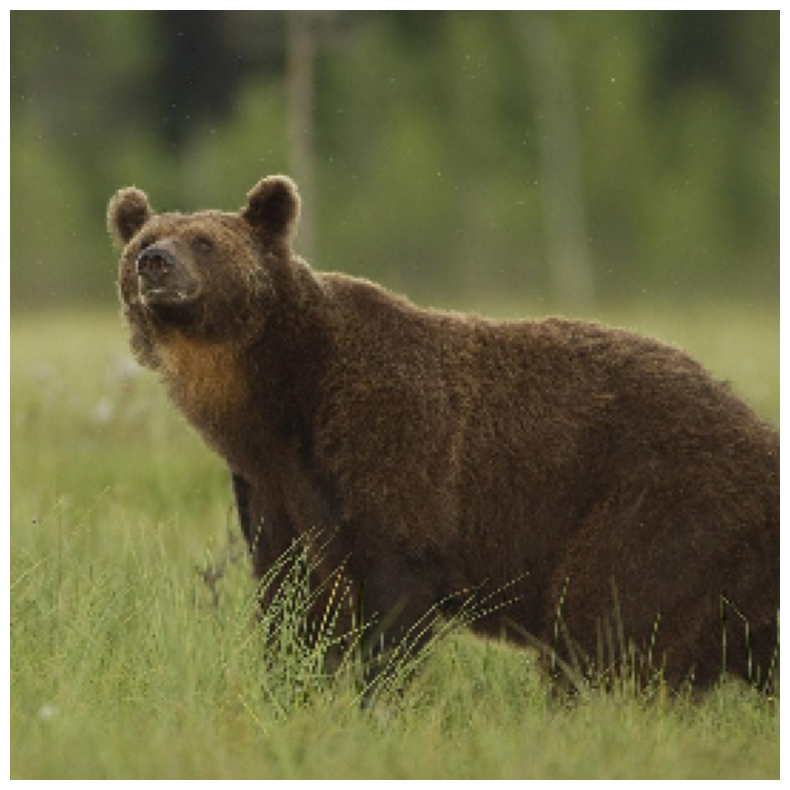

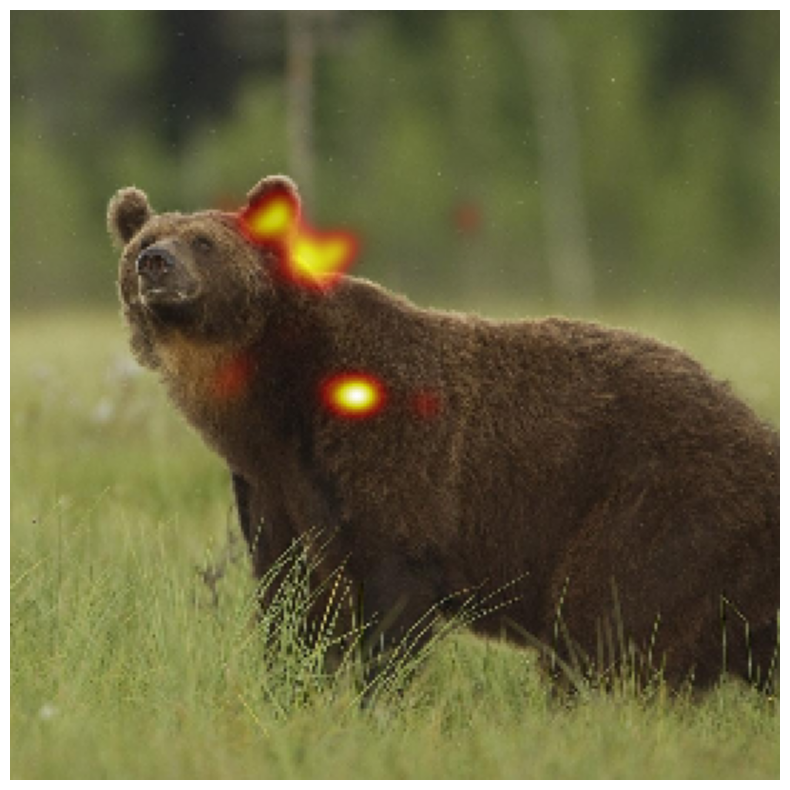

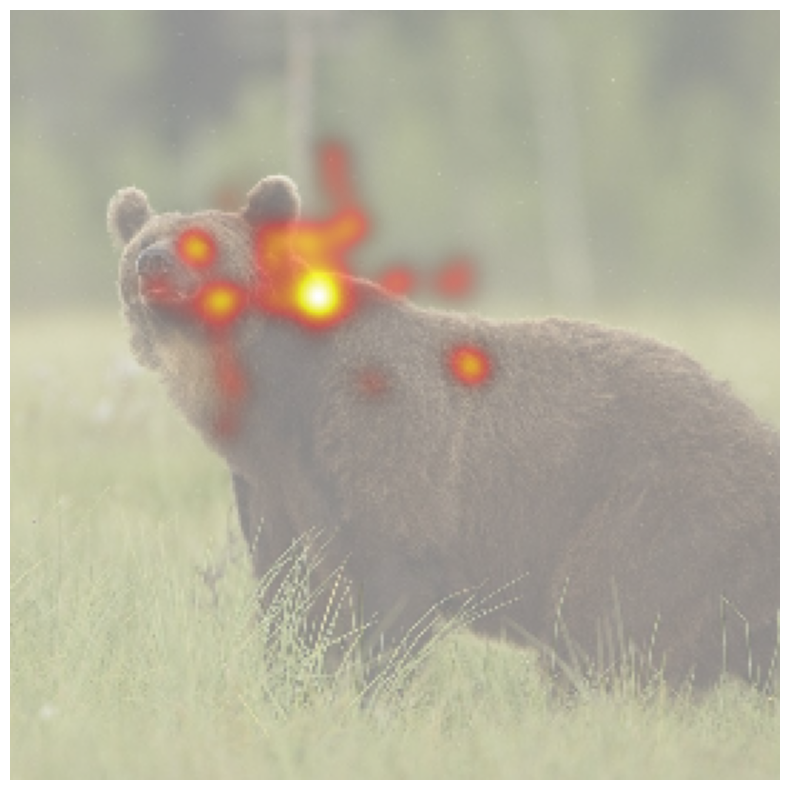

In [ ]:
egImage = cv2.imread('images/bear/bear_08s.jpg'.split('/')[-1])
egImage = cv2.cvtColor(egImage, cv2.COLOR_BGR2RGB)

plt.imshow(cv2.resize(egImage, (270,270)))
plt.axis('off')
plt.show()


jj = gaussian_filter(encodingHeatmapEg, sigma=5)
plt.imshow(cv2.resize(egImage, (270,270)), zorder=0, alpha = 1)
plt.imshow(jj,zorder = 1,alpha = jj.astype(np.float32)*(1/np.max(jj)),cmap='hot',vmin = 0, )
plt.axis('off')
plt.show()
jj = gaussian_filter(delayHeatmapEg, sigma=5)
plt.imshow(cv2.resize(egImage, (270,270)), zorder=0, alpha = 0.5)
plt.imshow(jj,zorder = 1,alpha = jj.astype(np.float32)*(1/np.max(jj)),cmap='hot',vmin = 0, )
plt.axis('off')
plt.show()



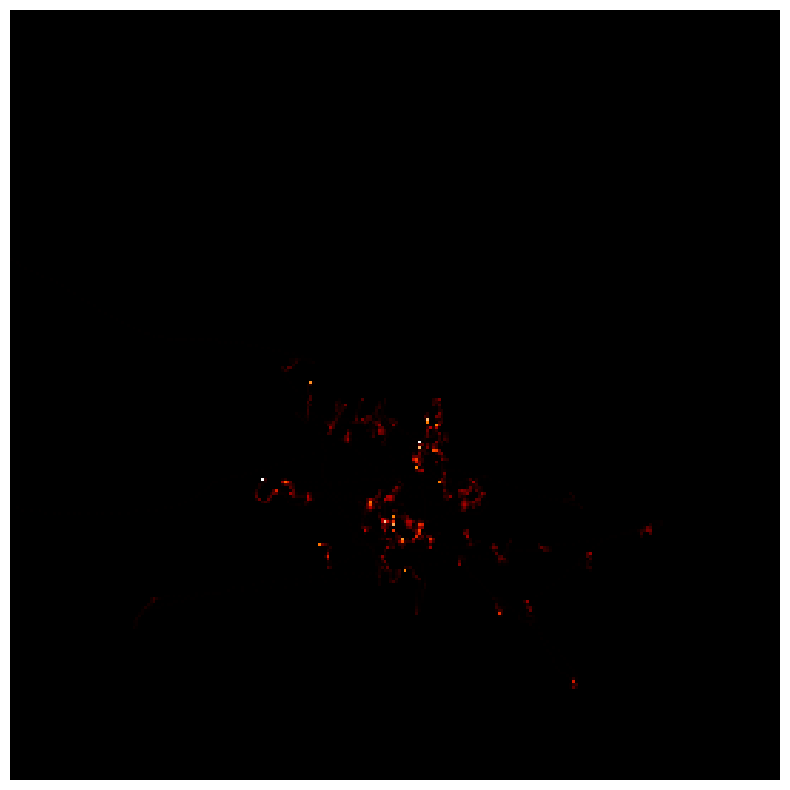

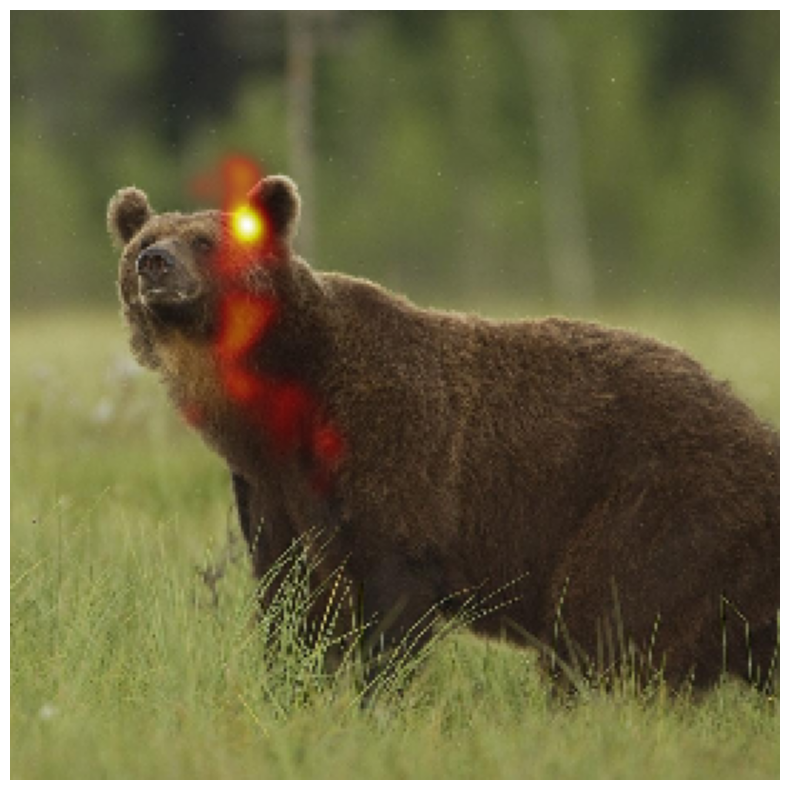

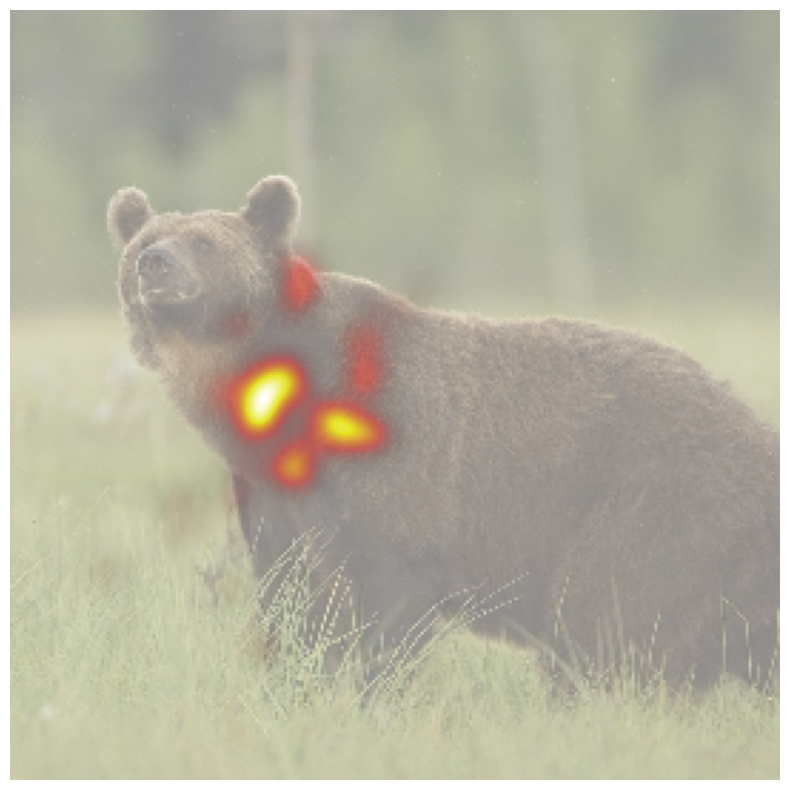

In [32]:
fs(10,10)
#exp related variables
imagePosX = [960-270,960+270]
imagePosY = [540-270,540+270]
bearTrlsAll = psyFull[(psyFull.stimImage == 'images/bear/bear_08s.jpg')&(psyFull.participant == 373)].TRIALID


thisX_stim = saccClean[saccClean.TRIALID.isin(bearTrlsAll)].loc['x'].iloc[:,stimStart:stimEnds].to_numpy().flatten()
thisX_delay = saccClean[saccClean.TRIALID.isin(bearTrlsAll)].loc['x'].iloc[:,delayStart:delayEnds].to_numpy().flatten()

thisY_stim = saccClean[saccClean.TRIALID.isin(bearTrlsAll)].loc['y'].iloc[:,stimStart:stimEnds].to_numpy().flatten()
thisY_delay = saccClean[saccClean.TRIALID.isin(bearTrlsAll)].loc['y'].iloc[:,delayStart:delayEnds].to_numpy().flatten()

#in psychopy we used default units 'height', screen size in height units [+-8/9, +-1/2]
#upper right corner of the image: [270. 270.] when using posToPix
encodingHeatmapEg = plt.hist2d(thisX_stim, thisY_stim, bins = (270,270),range = [imagePosX, imagePosY],
                    density=True,cmap = 'gist_heat',)[0];
delayHeatmapEg = plt.hist2d(thisX_delay, thisY_delay, bins = (270,270),range = [imagePosX, imagePosY],
                    density=True,cmap = 'gist_heat',)[0];

egImage = cv2.imread('C:/Users/yud070/Desktop/gazeObject_YueyingZoe/expImages40/' + 'images/bear/bear_08s.jpg'.split('/')[-1])
egImage = cv2.cvtColor(egImage, cv2.COLOR_BGR2RGB)

plt.imshow(cv2.resize(egImage, (270,270)))
plt.axis('off')
plt.show()


jj = gaussian_filter(encodingHeatmapEg, sigma=5)
plt.imshow(cv2.resize(egImage, (270,270)), zorder=0, alpha = 1)
plt.imshow(jj,zorder = 1,alpha = jj.astype(np.float32)*(1/np.max(jj)),cmap='hot',vmin = 0, )
plt.axis('off')
plt.show()

jj = gaussian_filter(delayHeatmapEg, sigma=5)
plt.imshow(cv2.resize(egImage, (270,270)), zorder=0, alpha = 0.5)
plt.imshow(jj,zorder = 1,alpha = jj.astype(np.float32)*(1/np.max(jj)),cmap='hot',vmin = 0, )
plt.axis('off')
plt.show()

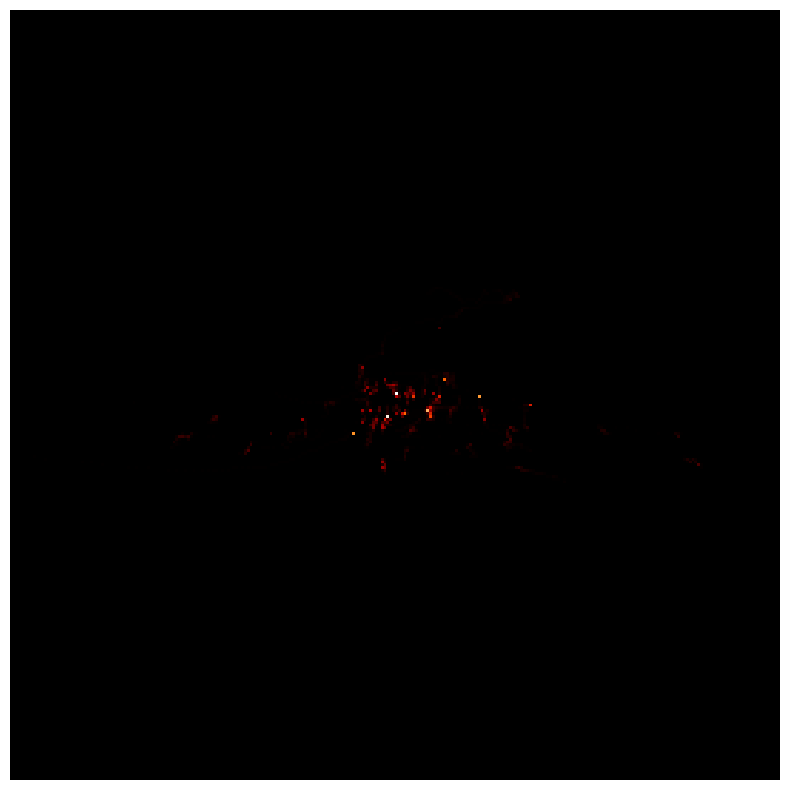

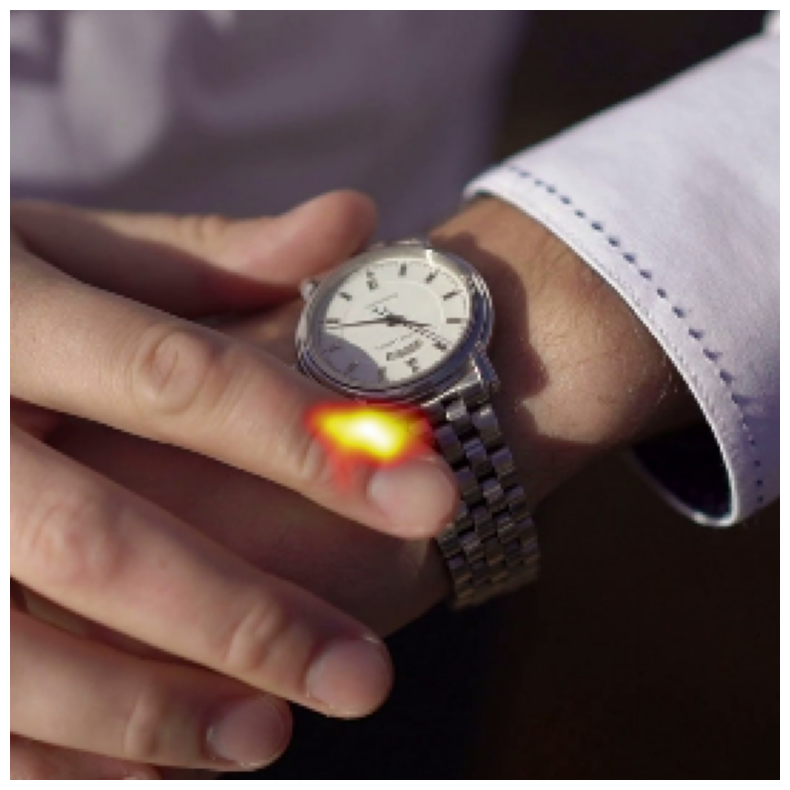

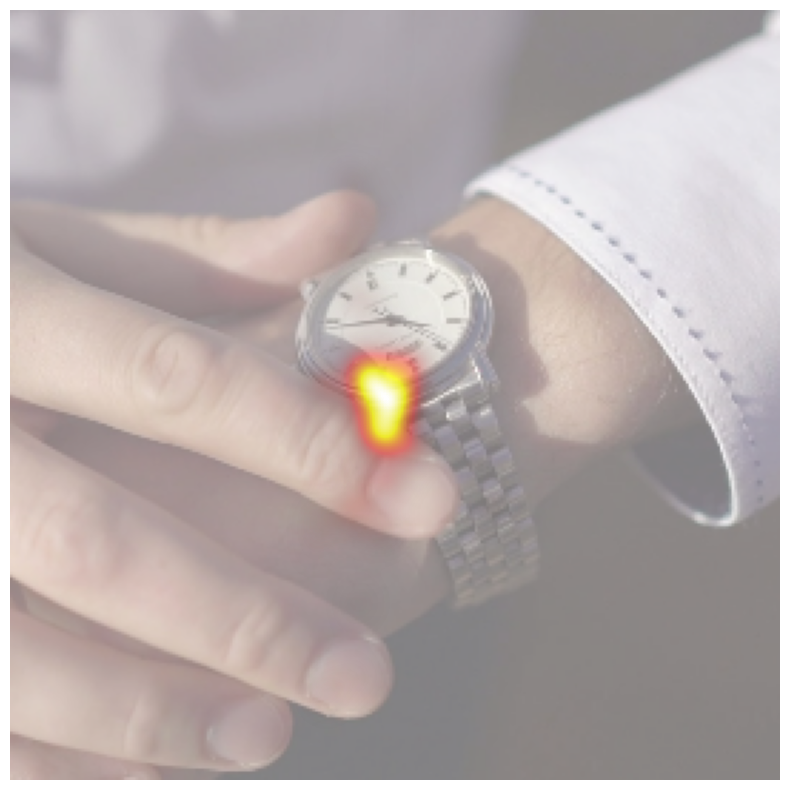

In [28]:
fs(10,10)
#exp related variables
imagePosX = [960-270,960+270]
imagePosY = [540-270,540+270]
bearTrlsAll = psyFull[(psyFull.stimImage == 'images/watch/watch_05s.jpg')&(psyFull.participant == 362)].TRIALID


thisX_stim = saccClean[saccClean.TRIALID.isin(bearTrlsAll)].loc['x'].iloc[:,stimStart:stimEnds].to_numpy().flatten()
thisX_delay = saccClean[saccClean.TRIALID.isin(bearTrlsAll)].loc['x'].iloc[:,delayStart:delayEnds].to_numpy().flatten()

thisY_stim = saccClean[saccClean.TRIALID.isin(bearTrlsAll)].loc['y'].iloc[:,stimStart:stimEnds].to_numpy().flatten()
thisY_delay = saccClean[saccClean.TRIALID.isin(bearTrlsAll)].loc['y'].iloc[:,delayStart:delayEnds].to_numpy().flatten()

#in psychopy we used default units 'height', screen size in height units [+-8/9, +-1/2]
#upper right corner of the image: [270. 270.] when using posToPix
encodingHeatmapEg = plt.hist2d(thisX_stim, thisY_stim, bins = (270,270),range = [imagePosX, imagePosY],
                    density=True,cmap = 'gist_heat',)[0];
delayHeatmapEg = plt.hist2d(thisX_delay, thisY_delay, bins = (270,270),range = [imagePosX, imagePosY],
                    density=True,cmap = 'gist_heat',)[0];

egImage = cv2.imread('C:/Users/yud070/Desktop/gazeObject_YueyingZoe/expImages40/' + 'images/watch/watch_05s.jpg'.split('/')[-1])
egImage = cv2.cvtColor(egImage, cv2.COLOR_BGR2RGB)

plt.imshow(cv2.resize(egImage, (270,270)))
plt.axis('off')
plt.show()


jj = gaussian_filter(encodingHeatmapEg, sigma=5)
plt.imshow(cv2.resize(egImage, (270,270)), zorder=0, alpha = 1)
plt.imshow(jj,zorder = 1,alpha = jj.astype(np.float32)*(1/np.max(jj)),cmap='hot',vmin = 0, )
plt.axis('off')
plt.show()

jj = gaussian_filter(delayHeatmapEg, sigma=5)
plt.imshow(cv2.resize(egImage, (270,270)), zorder=0, alpha = 0.5)
plt.imshow(jj,zorder = 1,alpha = jj.astype(np.float32)*(1/np.max(jj)),cmap='hot',vmin = 0, )
plt.axis('off')
plt.show()

# prepare data for scan path

In [40]:

stimStart = 500
stimEnds = 1500
delayStart = 4000
delayEnds = 5000
"""
#precue
stimStart = 1500
stimEnds = 2500
delayStart = 4000
delayEnds = 5000"""


'\n#precue\nstimStart = 1500\nstimEnds = 2500\ndelayStart = 4000\ndelayEnds = 5000'

In [42]:
smoothSaccX_stim = smoothSaccX.iloc[:,stimStart:stimEnds]
smoothSaccY_stim = smoothSaccY.iloc[:,stimStart:stimEnds]

smoothSaccX_delay = smoothSaccX.iloc[:,delayStart:delayEnds]
smoothSaccY_delay = smoothSaccY.iloc[:,delayStart:delayEnds]



In [43]:
#the ScanMatch package requirs the data to be stored in x,y,duration format.
#i do this for every trial
fixationArrX_stim = []
fixationArrY_stim = []
fixationDurationEach_stim = []

for q in range(len(smoothSaccX_stim)):
    saccLoc = np.where(shiftDf_relX[q,stimStart:stimEnds]!=0)[0]
    try:
        if saccLoc[0] != 0: 
            saccLoc = np.r_[0,saccLoc,]
        if saccLoc[-1] != delayStart-stimStart:
            saccLoc = np.r_[saccLoc,delayStart-stimStart]
    except IndexError:
        pass 
    fixationArrX_stim.append([int(smoothSaccX_stim.iloc[q,i:j].mean()) for i,j in zip(saccLoc[:-1],saccLoc[1:]) ])
    fixationArrY_stim.append([int(smoothSaccY_stim.iloc[q,i:j].mean()) for i,j in zip(saccLoc[:-1],saccLoc[1:]) ])
    fixationDurationEach_stim.append((saccLoc[1:] - saccLoc[:-1])/1000)

In [44]:
#the ScanMatch package requirs the data to be stored in x,y,duration format.
#i do this for every trial
fixationArrX_delay = []
fixationArrY_delay = []
fixationDurationEach_delay = []

for q in range(len(smoothSaccX_delay)):
    saccLoc = np.where(shiftDf_relX[q,delayStart:delayEnds]!=0)[0]
    try:
        if saccLoc[0] != 0: 
            saccLoc = np.r_[0,saccLoc,]
        if saccLoc[-1] != delayEnds-delayStart:
            saccLoc = np.r_[saccLoc,delayEnds-delayStart]
    except IndexError:
        pass 
    fixationArrX_delay.append([int(smoothSaccX_delay.iloc[q,i:j].mean()) for i,j in zip(saccLoc[:-1],saccLoc[1:]) ])
    fixationArrY_delay.append([int(smoothSaccY_delay.iloc[q,i:j].mean()) for i,j in zip(saccLoc[:-1],saccLoc[1:]) ])
    fixationDurationEach_delay.append((saccLoc[1:] - saccLoc[:-1])/1000)

In [45]:
#fix the trial label, otherwise matlab will throw an error, now the trial label looks like t_111_1_1
trlLabels = ['t' + i.replace("'",'').replace("(",'').replace(")",'').replace(", ",'_').replace(" ",'') for i in saccClean.loc['x'].TRIALID.values]

mat_stim = [np.vstack((i,k,j)).T for i,k,j in zip(fixationArrX_stim,fixationArrY_stim,fixationDurationEach_stim)] #formatting
mat_delay = [np.vstack((i,k,j)).T for i,k,j in zip(fixationArrX_delay,fixationArrY_delay,fixationDurationEach_delay)] #formatting

outMat_stim = dict(zip(trlLabels,mat_stim)) 
outMat_delay = dict(zip(trlLabels,mat_delay)) 


In [46]:
temp = pd.DataFrame(saccClean.loc['x'].TRIALID)
temp['subj'] = [ast.literal_eval(i)[0]  for i in temp.TRIALID]

In [ ]:
workspace_path = 'D:/yueying/gazeObject_YueyingDong/results/variables/scanMatchVariables/360to400_stim2delay_1sdelay/'

indexer = np.r_[0,temp.subj.value_counts().sort_index().cumsum().values]
for n,(indexStart,indexEnds) in enumerate(zip(indexer[:-1],indexer[1:])):
    

    a = dict(list(outMat_stim.items())[indexStart:indexEnds])
    b = dict(list(outMat_delay.items())[indexStart:indexEnds])
    c = trlLabels[indexStart:indexEnds]

    subj = c[0][1:4]
    outMat_stim_name = str(subj)+ '_scanMatch_stim.mat'
    outMat_delay_name = str(subj)+ '_scanMatch_delay.mat'

    print(subj,len(c))

    # check if the file exists, if not, save
    for pathName, item in zip(
        [outMat_stim_name,outMat_delay_name],
        [a,b]):
        if os.path.exists(workspace_path+ pathName):
            #print(f"File {pathName} exists")
            pass
        else:
            scipy.io.savemat(workspace_path+ pathName,item)
            np.save('D:/yueying/gazeObject_YueyingDong/results/variables/scanMatchTrlID/360to400_stim2delay_1sdelay/' +str(subj) +'_saccTrlIDs.npy',c)


112 298
360 317
362 275
363 307
364 318
365 317
366 319
367 284
368 302
369 313
370 298
371 314
372 255
373 297
374 292
375 319
376 309
377 318
378 308
379 318
380 316
381 302
382 264
383 269
384 255
385 272
386 310
387 308
388 317
389 316
390 316
391 305
392 285
393 291
394 271
395 307
396 299
397 262
398 314
399 297
400 319


In [ ]:
subj = '360to400'
#names for the variables
outMat_stim_name = subj+ '_scanMatch_stim.mat'
outMat_delay_name = subj+ '_scanMatch_delay.mat'

# check if the file exists, if not, save
for pathName, item in zip(
    [outMat_stim_name,outMat_delay_name],
    [outMat_stim,outMat_delay]):
    if os.path.exists(workspace_path+ pathName):
        print(f"File {pathName} exists")
        pass
    else:
        scipy.io.savemat(workspace_path+ pathName,item)

saccTrlIDs = saccClean.loc['x'].TRIALID.values
np.save(subj +'_saccTrlIDs.npy',saccTrlIDs)


''